<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection_fasterRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Faster R-CNN Traffic Sign Detection

Two-stage detector (RPN + classifier/regressor) trained on the car detection dataset. This notebook reports loss/mAP curves, PR curve, and a confusion matrix.

In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME", "")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY", "")

if not os.environ["KAGGLE_USERNAME"] or not os.environ["KAGGLE_KEY"]:
    print("Kaggle credentials not found in Colab userdata.")

!pip install -q kaggle

import zipfile
from pathlib import Path

extract_dir = Path("cardetection_dataset")
zip_path = Path("cardetection.zip")

if not extract_dir.exists():
    !kaggle datasets download -d pkdarabi/cardetection

    if zip_path.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"Dataset extracted to {extract_dir}")
else:
    print(f"Dataset already exists at {extract_dir}")

## Setup & Environment

In [1]:
import os
import sys
import subprocess
import importlib

# Helper function to check and install packages with guards
def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name.split("[")[0]  # Handle packages like 'torchmetrics[detection]'
    
    try:
        importlib.import_module(import_name)
        print(f"✓ {package_name} already installed")
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
        print(f"✓ {package_name} installed successfully")

In [2]:
# Install dependencies with guards
install_if_missing("pycocotools", "pycocotools")
install_if_missing("torchmetrics[detection]", "torchmetrics")

✓ pycocotools already installed


c:\Users\Panda\Downloads\171\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ torchmetrics[detection] already installed


In [3]:
import yaml
import torch
import torch.optim
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

## Environment & Device Setup

In [ ]:
# Setup device agnostic code
frcnn_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {frcnn_device}")

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi

Using device: cuda


## Data Preparation

In [5]:
def load_class_names(yaml_path):
    """Load class names from YAML file"""
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)
    return data.get("names", [])


class YoloDetectionDataset(Dataset):
    """Dataset class for YOLO-format annotations"""
    def __init__(self, img_dir, label_dir, class_offset=1, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.class_offset = class_offset
        self.transforms = transforms
        self.images = [
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)
        label_path = os.path.join(self.label_dir, os.path.splitext(img_file)[0] + ".txt")

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    class_id, x, y, w, h = map(float, parts)
                    xmin = max(0.0, (x - w / 2) * width)
                    ymin = max(0.0, (y - h / 2) * height)
                    xmax = min(width, (x + w / 2) * width)
                    ymax = min(height, (y + h / 2) * height)
                    if xmax <= xmin or ymax <= ymin:
                        continue
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(class_id) + self.class_offset)

        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([index]),
            "area": area,
            "iscrowd": torch.zeros((labels.shape[0],), dtype=torch.int64),
        }

        if self.transforms:
            image = self.transforms(image)

        return image, target


def collate_fn(batch):
    """Custom collate function for DataLoader"""
    return tuple(zip(*batch))

In [6]:
# Load class names and configuration
frcnn_yaml_path = "cardetection_dataset/car/data.yaml"
frcnn_class_names = load_class_names(frcnn_yaml_path)
FRCNN_NUM_CLASSES = len(frcnn_class_names) + 1  # +1 for background class

print(f"Number of classes: {FRCNN_NUM_CLASSES}")
print(f"Class names: {frcnn_class_names}")

Number of classes: 16
Class names: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


In [7]:
# Create datasets with guard to prevent reloading
if 'frcnn_train_dataset' not in locals():
    print("Loading training dataset...")
    frcnn_train_dataset = YoloDetectionDataset(
        img_dir="cardetection_dataset/car/train/images",
        label_dir="cardetection_dataset/car/train/labels",
        transforms=transforms.ToTensor(),
    )
    print(f"✓ Training dataset loaded: {len(frcnn_train_dataset)} images")
else:
    print("✓ Training dataset already loaded")

if 'frcnn_val_dataset' not in locals():
    print("Loading validation dataset...")
    frcnn_val_dataset = YoloDetectionDataset(
        img_dir="cardetection_dataset/car/valid/images",
        label_dir="cardetection_dataset/car/valid/labels",
        transforms=transforms.ToTensor(),
    )
    print(f"✓ Validation dataset loaded: {len(frcnn_val_dataset)} images")
else:
    print("✓ Validation dataset already loaded")

if 'frcnn_test_dataset' not in locals():
    print("Loading test dataset...")
    frcnn_test_dataset = YoloDetectionDataset(
        img_dir="cardetection_dataset/car/test/images",
        label_dir="cardetection_dataset/car/test/labels",
        transforms=transforms.ToTensor(),
    )
    print(f"✓ Test dataset loaded: {len(frcnn_test_dataset)} images")
else:
    print("✓ Test dataset already loaded")

Loading training dataset...
✓ Training dataset loaded: 3530 images
Loading validation dataset...
✓ Validation dataset loaded: 801 images
Loading test dataset...
✓ Test dataset loaded: 638 images


In [8]:
# Create DataLoaders with guard to prevent reloading
if 'frcnn_train_loader' not in locals():
    print("Creating DataLoaders...")
    frcnn_train_loader = DataLoader(
        frcnn_train_dataset,
        batch_size=4,
        shuffle=True,
        num_workers=0,  # Modified to prevent deadlock
        collate_fn=collate_fn,
    )

    frcnn_val_loader = DataLoader(
        frcnn_val_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,  # Modified to prevent deadlock
        collate_fn=collate_fn,
    )

    frcnn_test_loader = DataLoader(
        frcnn_test_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,  # Modified to prevent deadlock
        collate_fn=collate_fn,
    )
    print("✓ DataLoaders created")
else:
    print("✓ DataLoaders already created")

Creating DataLoaders...
✓ DataLoaders created


## Model Setup

In [9]:
# Initialize model with guard to prevent reloading
if 'frcnn_model' not in locals() or frcnn_model is None:
    print("Loading Faster R-CNN model...")
    frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = frcnn_model.roi_heads.box_predictor.cls_score.in_features
    frcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, FRCNN_NUM_CLASSES)
    frcnn_model.to(frcnn_device)
    print(f"✓ Model loaded and moved to {frcnn_device}")
else:
    print("✓ Model already initialized")

Loading Faster R-CNN model...
✓ Model loaded and moved to cuda


In [10]:
# Initialize optimizer with guard
if 'frcnn_optimizer' not in locals() or frcnn_optimizer is None:
    print("Creating optimizer...")
    frcnn_optimizer = torch.optim.AdamW(
        frcnn_model.parameters(),
        lr=1e-4,
        weight_decay=1e-4,
    )
    print("✓ Optimizer created")
else:
    print("✓ Optimizer already created")

Creating optimizer...
✓ Optimizer created


## Training Functions

In [11]:
def frcnn_train_one_epoch(model, loader, optimizer, device, epoch, total_epochs):
    """Train model for one epoch"""
    model.train()
    running_loss = 0.0
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [Train]", leave=False)
    
    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        
        progress_bar.set_postfix(loss=f"{losses.item():.4f}")

    return running_loss / max(1, len(loader))



def frcnn_eval_map(model, loader, device, epoch, total_epochs):
    """Evaluate model on validation/test set"""
    model.eval()
    # Request extended summary so precision/recall tensors are available for plotting
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", extended_summary=True)
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [Val]", leave=False)
    
    with torch.inference_mode():
        for images, targets in progress_bar:
            images = [img.to(device) for img in images]
            preds = model(images)
            preds = [{k: v.detach().cpu() for k, v in p.items()} for p in preds]
            targets = [{k: v.detach().cpu() for k, v in t.items()} for t in targets]
            metric.update(preds, targets)
            
    return metric.compute()

## Training Loop

In [12]:
# Training with guard to prevent retraining
FRCNN_EPOCHS = 5

if 'frcnn_train_losses' not in locals():
    print(f"Starting training for {FRCNN_EPOCHS} epochs...")
    frcnn_train_losses = []
    frcnn_val_map50 = []

    for epoch in range(FRCNN_EPOCHS):
        current_epoch = epoch + 1
        
        loss = frcnn_train_one_epoch(
            frcnn_model, 
            frcnn_train_loader, 
            frcnn_optimizer, 
            frcnn_device, 
            current_epoch, 
            FRCNN_EPOCHS
        )
        
        metrics = frcnn_eval_map(
            frcnn_model, 
            frcnn_val_loader, 
            frcnn_device, 
            current_epoch, 
            FRCNN_EPOCHS
        )

        frcnn_train_losses.append(loss)
        frcnn_val_map50.append(float(metrics["map_50"]))

        print(f"Epoch {current_epoch}/{FRCNN_EPOCHS} Summary | Avg Train Loss: {loss:.4f} | mAP50: {metrics['map_50']:.4f}")
    
    print("\n✓ Training completed")
else:
    print("✓ Model already trained")

Starting training for 5 epochs...


Epoch 1/5 Summary | Avg Train Loss: 0.1900 | mAP50: 0.3911


Epoch 2/5 Summary | Avg Train Loss: 0.1279 | mAP50: 0.7148


Epoch 3/5 Summary | Avg Train Loss: 0.0982 | mAP50: 0.8596


Epoch 4/5 Summary | Avg Train Loss: 0.0797 | mAP50: 0.8964


Epoch 5/5 Summary | Avg Train Loss: 0.0701 | mAP50: 0.9365

✓ Training completed


## Evaluation & Visualization Functions

In [13]:
def frcnn_plot_curves(train_losses, map50_values):
    """Plot training loss and validation mAP50 curves"""
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train loss", color="blue", marker="o")
    plt.plot(epochs, map50_values, label="Val mAP50", color="green", marker="x")
    plt.title("Faster R-CNN: Loss and mAP50")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()
    plt.show()


def frcnn_plot_pr_curve(map_results):
    """Plot Precision-Recall curve"""
    precision = map_results.get("precision")
    if not isinstance(precision, torch.Tensor) or precision.numel() == 0:
        print("PR curve data not available.")
        return
    # precision shape: [T, R, K, A, M]
    precision = precision[0, :, :, 0, 0]
    precision = torch.nanmean(precision, dim=1)
    recall = torch.linspace(0, 1, precision.shape[0])

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color="purple")
    plt.title("Faster R-CNN: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.show()


def frcnn_collect_predictions(model, loader, device, score_thresh=0.25):
    """Collect predictions from the model"""
    model.eval()
    all_preds = []
    all_targets = []
    with torch.inference_mode():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            preds = model(images)
            for pred, target in zip(preds, targets):
                keep = pred["scores"].detach().cpu() >= score_thresh
                filtered_pred = {
                    "boxes": pred["boxes"].detach().cpu()[keep],
                    "labels": pred["labels"].detach().cpu()[keep],
                    "scores": pred["scores"].detach().cpu()[keep],
                }
                all_preds.append(filtered_pred)
                all_targets.append({
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu(),
                })
    return all_preds, all_targets


def frcnn_build_confusion(preds, targets, class_names, iou_thresh=0.5):
    """Build confusion matrix from predictions and targets"""
    y_true = []
    y_pred = []
    background = len(class_names)

    for pred, target in zip(preds, targets):
        t_boxes = target["boxes"]
        t_labels = target["labels"] - 1
        p_boxes = pred["boxes"]
        p_labels = pred["labels"] - 1

        if len(t_boxes) == 0 and len(p_boxes) == 0:
            continue
        if len(t_boxes) == 0:
            y_true.extend([background] * len(p_boxes))
            y_pred.extend(p_labels.tolist())
            continue
        if len(p_boxes) == 0:
            y_true.extend(t_labels.tolist())
            y_pred.extend([background] * len(t_boxes))
            continue

        ious = box_iou(t_boxes, p_boxes)
        matched_preds = set()

        for t_idx, t_label in enumerate(t_labels):
            best_iou, p_idx = ious[t_idx].max(dim=0)
            if best_iou >= iou_thresh:
                y_true.append(int(t_label))
                y_pred.append(int(p_labels[p_idx]))
                matched_preds.add(int(p_idx))
            else:
                y_true.append(int(t_label))
                y_pred.append(background)

        for p_idx, p_label in enumerate(p_labels):
            if int(p_idx) not in matched_preds:
                y_true.append(background)
                y_pred.append(int(p_label))

    return y_true, y_pred

## Results & Evaluation

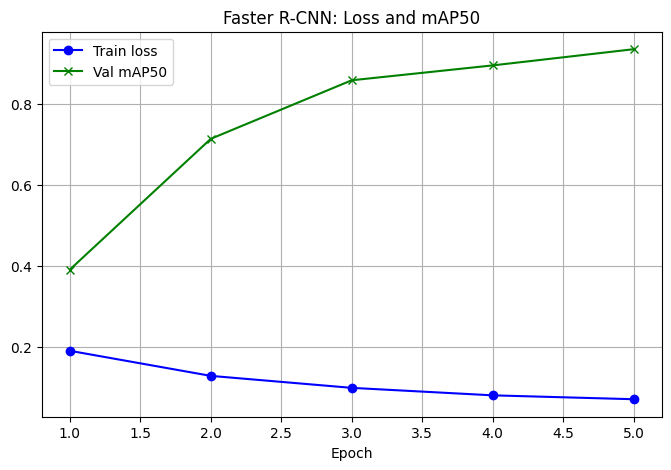

In [14]:
# Plot training curves
frcnn_plot_curves(frcnn_train_losses, frcnn_val_map50)

In [15]:
# Evaluate on test set
print("Evaluating on test set...")
frcnn_test_results = frcnn_eval_map(frcnn_model, frcnn_test_loader, frcnn_device, 1, 1)
print(f"\nTest Set Results:")
print(f"mAP (IoU=0.50:0.95): {frcnn_test_results['map']:.4f}")
print(f"mAP (IoU=0.50): {frcnn_test_results['map_50']:.4f}")
print(f"mAP (IoU=0.75): {frcnn_test_results['map_75']:.4f}")

Evaluating on test set...



Test Set Results:
mAP (IoU=0.50:0.95): 0.6754
mAP (IoU=0.50): 0.8874
mAP (IoU=0.75): 0.8128


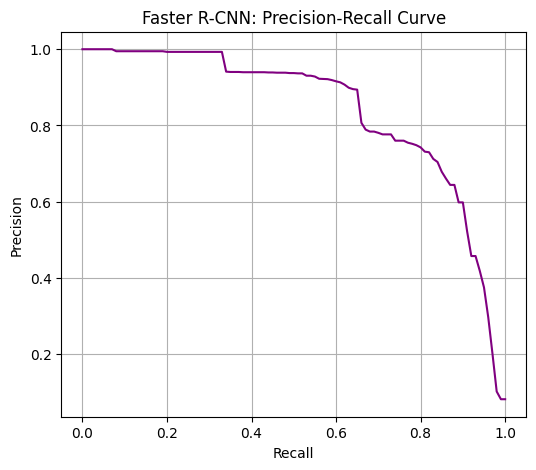

In [16]:
# Plot Precision-Recall curve
frcnn_plot_pr_curve(frcnn_test_results)

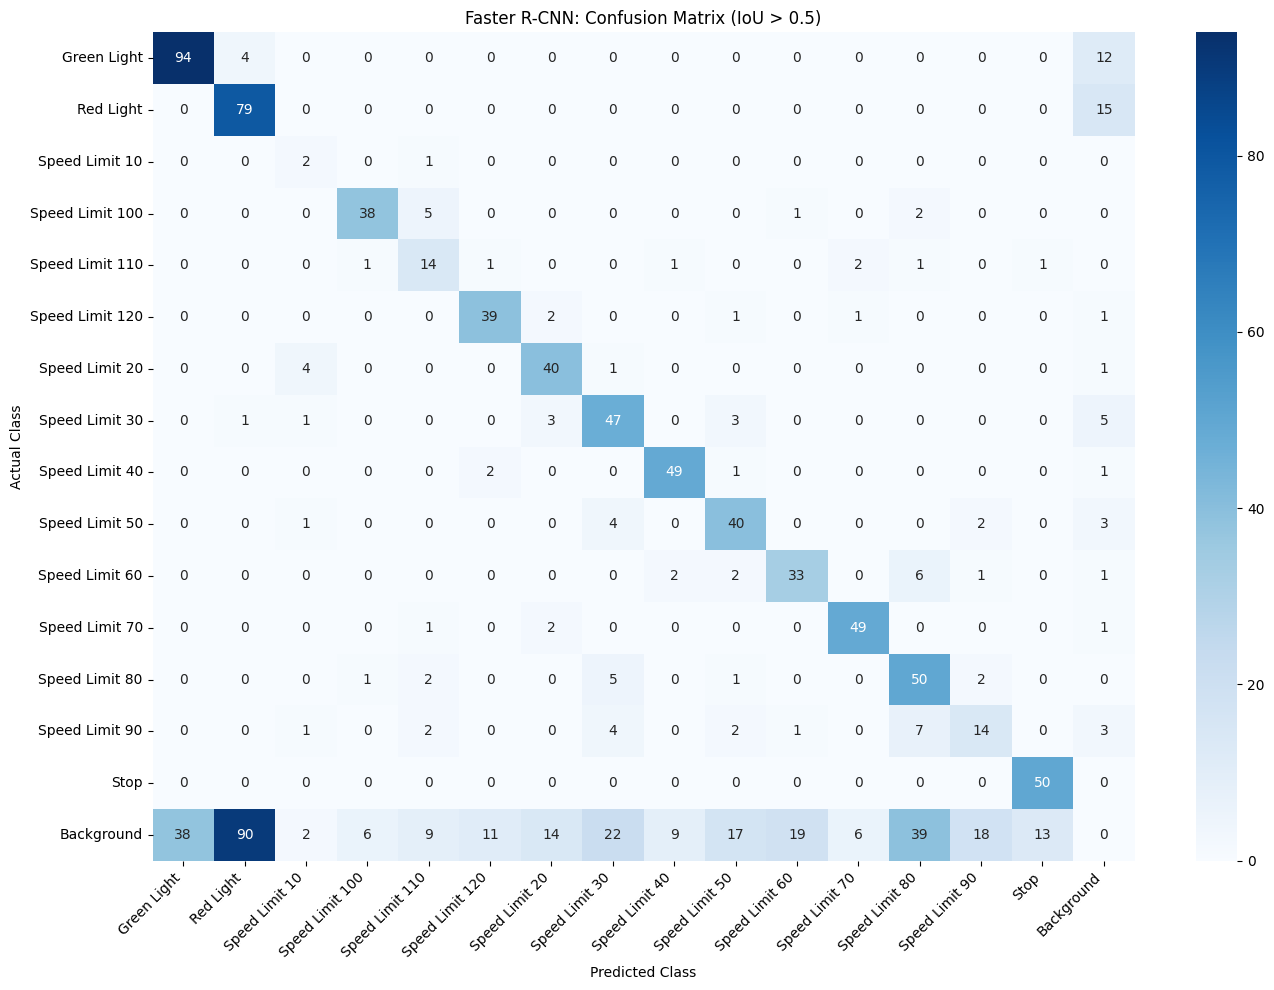

In [17]:
# Generate confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

frcnn_preds, frcnn_targets = frcnn_collect_predictions(
    frcnn_model,
    frcnn_test_loader,
    frcnn_device,
    score_thresh=0.25,
)

y_true, y_pred = frcnn_build_confusion(frcnn_preds, frcnn_targets, frcnn_class_names)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(frcnn_class_names) + 1)))
cm_labels = frcnn_class_names + ["Background"]

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cm_labels, yticklabels=cm_labels)
plt.title("Faster R-CNN: Confusion Matrix (IoU > 0.5)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()